# betula-cluster — quickstart

`betula-cluster` clusters large datasets in two phases: it compresses `N` points into a small,
numerically-stable **CF-tree** (memory bounded by `max_leaves`), then clusters the few leaf
summaries. This notebook walks through the one-shot API and every clustering head, with pictures.

```bash
pip install betula-cluster
```

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs

import betula_cluster
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", palette="deep")

print("betula-cluster", "ready")

betula-cluster ready


## Data — four Gaussian blobs

In [2]:
X, y = make_blobs(n_samples=20_000, centers=4, cluster_std=0.7, random_state=0)
X = X.astype(np.float64)
print("X:", X.shape)

X: (20000, 2)


## One-shot `fit_predict`

`feature ∈ {spherical, diagonal, full, fd}` selects the per-leaf covariance model;
`method ∈ {kmeans, gmm, gmm-full, ward, hdbscan}` is the global head.

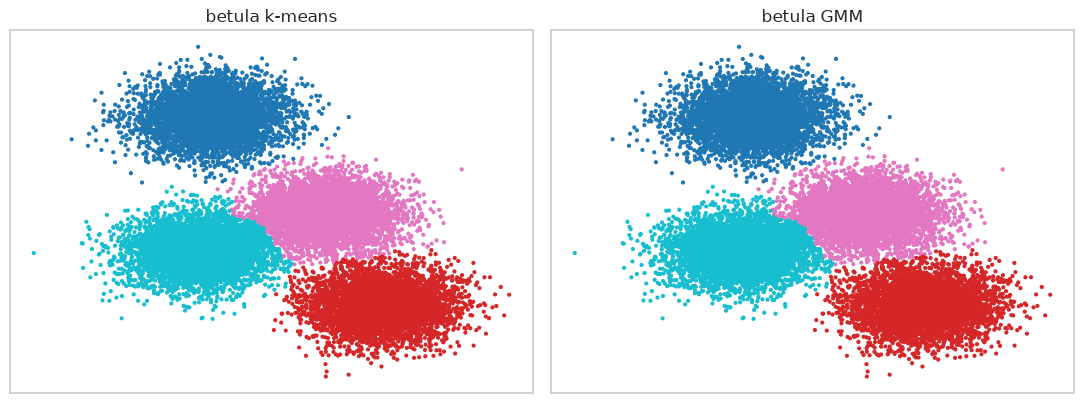

In [3]:
labels_km = betula_cluster.fit_predict(X, n_clusters=4, feature="diagonal", method="kmeans")
labels_gmm = betula_cluster.fit_predict(X, n_clusters=4, feature="diagonal", method="gmm")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for a, (lab, name) in zip(ax, [(labels_km, "k-means"), (labels_gmm, "GMM")], strict=True):
    a.scatter(X[:, 0], X[:, 1], c=lab, s=4, cmap="tab10")
    a.set_title(f"betula {name}")
    a.set_xticks([])
    a.set_yticks([])
fig.tight_layout()
plt.show()

## Automatic cluster count

With `n_clusters=0` the component count is chosen by BIC (k-means / GMM) or a dendrogram cut
(Ward) — no `k` needed.

In [4]:
auto = betula_cluster.fit_predict(X, n_clusters=0, feature="diagonal", method="gmm")
print("auto-selected k =", len({int(v) for v in auto}))

auto-selected k = 4


## Full-covariance GMM captures rotated clusters

`method="gmm-full"` with `feature="diagonal"` builds a **full** component covariance from the
between-leaf spread at `O(d)` build cost — it recovers correlated/rotated clusters that an
axis-aligned model cannot.

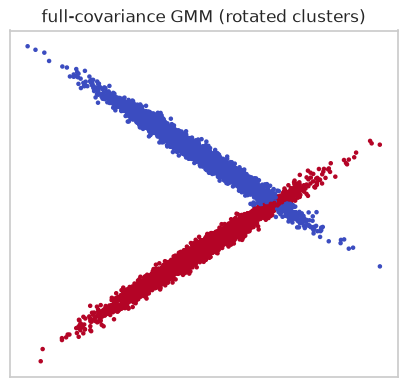

In [5]:
rng = np.random.default_rng(1)
A = rng.standard_normal((4000, 2)) @ np.array([[3.0, 2.4], [0.0, 0.4]]) + [0, 0]
B = rng.standard_normal((4000, 2)) @ np.array([[3.0, -2.4], [0.0, 0.4]]) + [0, 8]
Xr = np.vstack([A, B])
lab_full = betula_cluster.fit_predict(Xr, 2, feature="diagonal", method="gmm-full")

plt.figure(figsize=(5, 4.5))
plt.scatter(Xr[:, 0], Xr[:, 1], c=lab_full, s=5, cmap="coolwarm")
plt.title("full-covariance GMM (rotated clusters)")
plt.xticks([])
plt.yticks([])
plt.show()

## Non-convex shapes — HDBSCAN on the CF-tree

Density-based; `-1` marks noise.

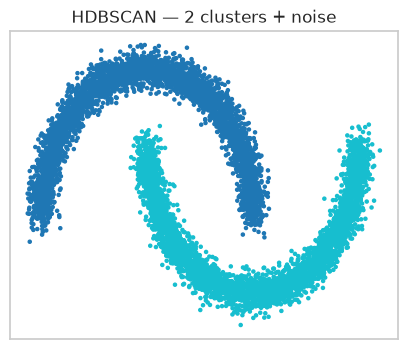

In [6]:
from sklearn.datasets import make_moons

Xm, ym = make_moons(n_samples=8000, noise=0.06, random_state=0)
lab_h = betula_cluster.fit_predict(
    Xm.astype(np.float64), method="hdbscan", min_samples=10, min_cluster_size=40
)
plt.figure(figsize=(5, 4))
plt.scatter(Xm[:, 0], Xm[:, 1], c=lab_h, s=5, cmap="tab10")
plt.title(f"HDBSCAN — {len({int(v) for v in lab_h if v >= 0})} clusters + noise")
plt.xticks([])
plt.yticks([])
plt.show()

## scikit-learn-style estimator

`Betula` is a drop-in estimator: `get_params`/`set_params`, `clone`, `Pipeline`, `GridSearchCV`,
and `save`/`load` + pickle all work.

In [7]:
est = betula_cluster.Betula(n_clusters=4, feature="diagonal", method="gmm").fit(X)
print("n_clusters_ =", est.n_clusters_, " n_leaves_ =", est.n_leaves_)
print("params:", {k: est.get_params()[k] for k in ("feature", "method", "n_clusters")})

n_clusters_ = 4  n_leaves_ = 1426
params: {'feature': 'diagonal', 'method': 'gmm', 'n_clusters': 4}
